In [28]:
# ÉTAPE 1 — Data Collection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
import warnings
warnings.filterwarnings('ignore')

# Chargement du dataset
df = pd.read_csv('dataset_mamaguard2.csv')

print("=" * 50)
print("   ÉTAPE 1 — DATA COLLECTION")
print("=" * 50)
print(f"\n Source : Dataset synthetique MamaGuard")
print(f" Valide par : 5 sage-femmes Hopital Bethesda Yaounde")
print(f"              + Gynecologue consultant")
print(f"              + Recommandations OMS 2022")
print(f"\n Nombre de cas collectes : {len(df)}")
print(f" Nombre de parametres    : {len(df.columns) - 1}")
print(f"\n Apercu des donnees brutes :")
print(df.head())

   ÉTAPE 1 — DATA COLLECTION

 Source : Dataset synthetique MamaGuard
 Valide par : 5 sage-femmes Hopital Bethesda Yaounde
              + Gynecologue consultant
              + Recommandations OMS 2022

 Nombre de cas collectes : 800
 Nombre de parametres    : 12

 Apercu des donnees brutes :
   bpm  temperature  spo2  tension_systolique  tension_diastolique  \
0   86         38.6    93                 132                   82   
1  110         39.7    82                 131                   90   
2   70         37.6    99                 109                   88   
3   71         38.1    98                 101                   65   
4  112         37.2    99                 100                   78   

   contractions_par_10min  semaine_grossesse   risque  pulse_pressure  \
0                       6                 14   Modere              50   
1                       6                 22    Eleve              41   
2                       2                  8  Normale            

In [29]:
# ÉTAPE 2 — Data Anonymization

print("=" * 50)
print("   ÉTAPE 2 — DATA ANONYMIZATION")
print("=" * 50)

# Notre dataset est déjà anonyme par nature
# Pas de nom, pas de numéro de dossier, pas d'adresse
# On le documente explicitement

print("""
 Verification de l'anonymisation :
 
 Colonnes presentes :
""")
for col in df.columns:
    print(f"   ✅ {col} — donnee medicale anonyme")

print("""
 Colonnes absentes (confirmees) :
   ✅ Aucun nom de patiente
   ✅ Aucun numero de dossier
   ✅ Aucune adresse
   ✅ Aucune date de naissance
   ✅ Aucun numero de telephone
   
 → Dataset conforme aux principes ethiques
   de protection des donnees medicales
""")

   ÉTAPE 2 — DATA ANONYMIZATION

 Verification de l'anonymisation :
 
 Colonnes presentes :

   ✅ bpm — donnee medicale anonyme
   ✅ temperature — donnee medicale anonyme
   ✅ spo2 — donnee medicale anonyme
   ✅ tension_systolique — donnee medicale anonyme
   ✅ tension_diastolique — donnee medicale anonyme
   ✅ contractions_par_10min — donnee medicale anonyme
   ✅ semaine_grossesse — donnee medicale anonyme
   ✅ risque — donnee medicale anonyme
   ✅ pulse_pressure — donnee medicale anonyme
   ✅ indice_tension — donnee medicale anonyme
   ✅ fievre — donnee medicale anonyme
   ✅ spo2_basse — donnee medicale anonyme
   ✅ trimestre — donnee medicale anonyme

 Colonnes absentes (confirmees) :
   ✅ Aucun nom de patiente
   ✅ Aucun numero de dossier
   ✅ Aucune adresse
   ✅ Aucune date de naissance
   ✅ Aucun numero de telephone
   
 → Dataset conforme aux principes ethiques
   de protection des donnees medicales



In [30]:
# ÉTAPE 3 — Data Cleaning

print("=" * 50)
print("   ÉTAPE 3 — DATA CLEANING")
print("=" * 50)

# 3.1 Vérifier les valeurs manquantes
print("\n 3.1 — Valeurs manquantes :")
print(df.isnull().sum())

# 3.2 Vérifier les doublons
doublons = df.duplicated().sum()
print(f"\n 3.2 — Doublons detectes : {doublons}")
if doublons > 0:
    df = df.drop_duplicates()
    print(f"   → {doublons} doublons supprimes")

# 3.3 Vérifier les types de données
print(f"\n 3.3 — Types de donnees :")
print(df.dtypes)

# 3.4 Vérifier les valeurs aberrantes
print(f"\n 3.4 — Detection des valeurs aberrantes :")

regles = {
    'bpm'                    : (30, 200),
    'temperature'            : (34.0, 42.0),
    'spo2'                   : (70, 100),
    'tension_systolique'     : (60, 220),
    'tension_diastolique'    : (40, 140),
    'contractions_par_10min' : (0, 20),
    'semaine_grossesse'      : (4, 44)
}

aberrants_total = 0
for colonne, (min_val, max_val) in regles.items():
    aberrants = df[
        (df[colonne] < min_val) | 
        (df[colonne] > max_val)
    ].shape[0]
    aberrants_total += aberrants
    statut = "✅ OK" if aberrants == 0 else f"⚠️  {aberrants} aberrants"
    print(f"   {colonne:<28} {statut}")

# Supprimer les valeurs aberrantes
for colonne, (min_val, max_val) in regles.items():
    df = df[
        (df[colonne] >= min_val) & 
        (df[colonne] <= max_val)
    ]

print(f"\n → {aberrants_total} valeurs aberrantes supprimees")
print(f" → Dataset propre : {len(df)} cas")
print("\n Data Cleaning termine ✅")

   ÉTAPE 3 — DATA CLEANING

 3.1 — Valeurs manquantes :
bpm                       0
temperature               0
spo2                      0
tension_systolique        0
tension_diastolique       0
contractions_par_10min    0
semaine_grossesse         0
risque                    0
pulse_pressure            0
indice_tension            0
fievre                    0
spo2_basse                0
trimestre                 0
dtype: int64

 3.2 — Doublons detectes : 0

 3.3 — Types de donnees :
bpm                         int64
temperature               float64
spo2                        int64
tension_systolique          int64
tension_diastolique         int64
contractions_par_10min      int64
semaine_grossesse           int64
risque                     object
pulse_pressure              int64
indice_tension            float64
fievre                      int64
spo2_basse                  int64
trimestre                   int64
dtype: object

 3.4 — Detection des valeurs aberrantes :
   bpm     

   ÉTAPE 4 — EDA

 4.1 — Statistiques descriptives :
          bpm  temperature    spo2  tension_systolique  tension_diastolique  \
count  600.00       600.00  600.00              600.00               600.00   
mean    98.60        37.64   95.04              129.48                83.53   
std     22.07         1.00    3.47               18.44                11.89   
min     60.00        36.10   85.00              100.00                65.00   
25%     81.75        36.90   93.00              115.75                74.75   
50%     98.00        37.50   95.00              129.00                84.00   
75%    115.00        38.20   98.00              141.00                90.00   
max    150.00        40.50  100.00              179.00               120.00   

       contractions_par_10min  semaine_grossesse  pulse_pressure  \
count                  600.00             600.00          600.00   
mean                     2.62              23.63           45.94   
std                      2.46  

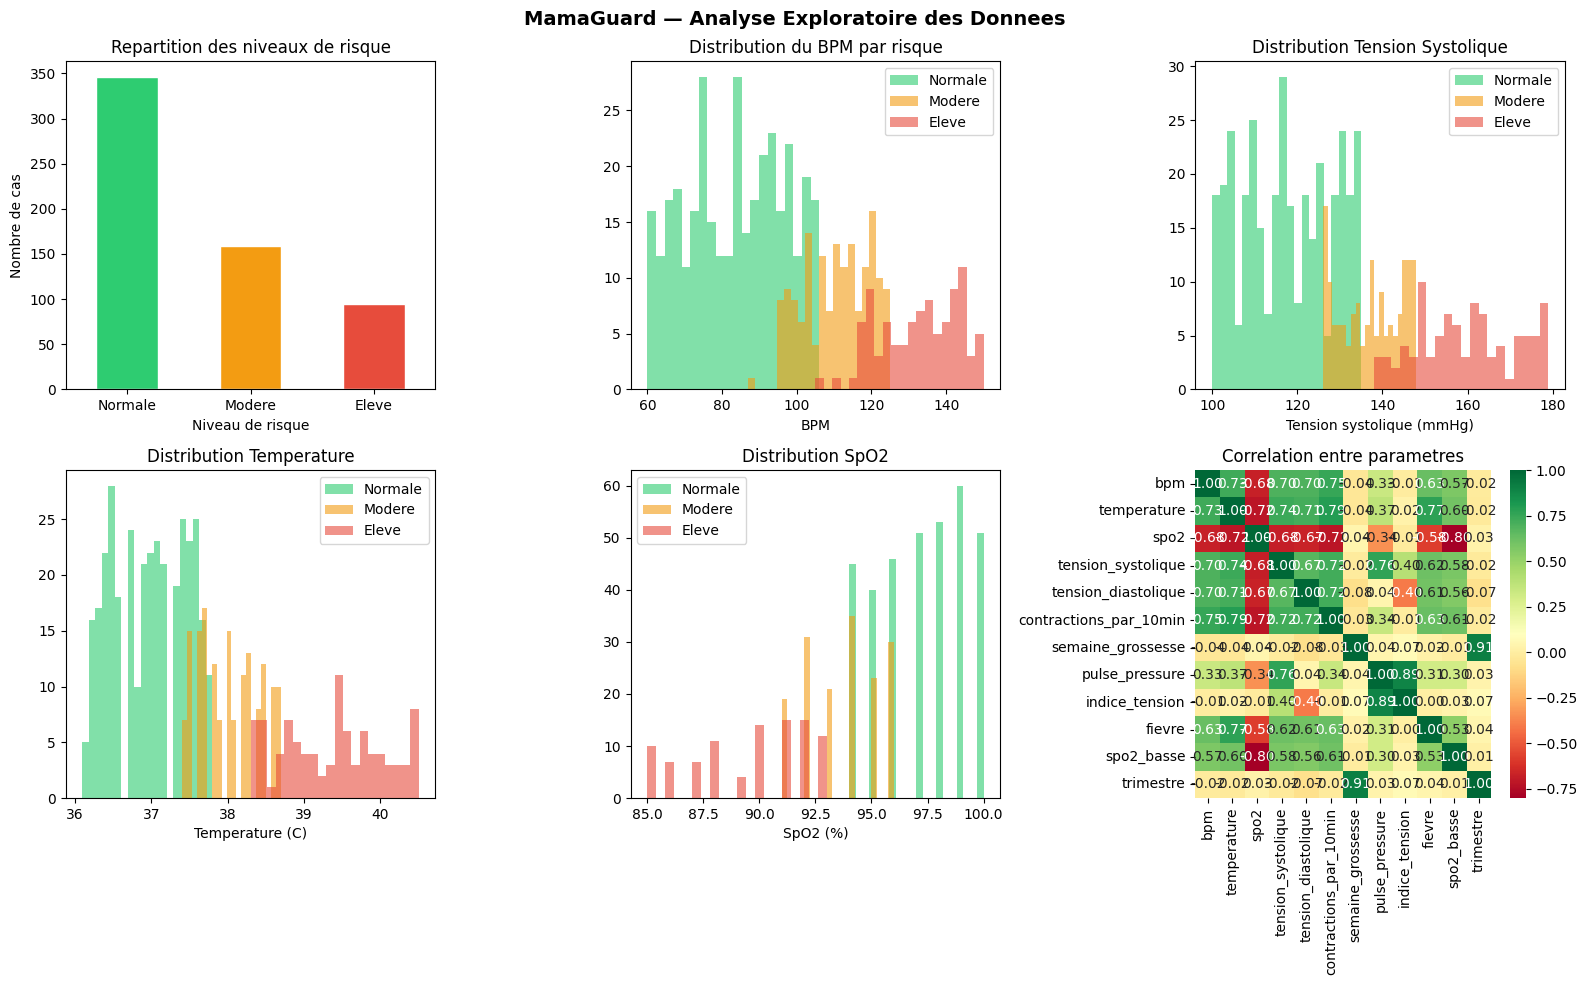


 EDA termine — graphiques sauvegardes ✅


In [18]:
# ÉTAPE 4 — Exploratory Data Analysis (EDA)

print("=" * 50)
print("   ÉTAPE 4 — EDA")
print("=" * 50)

# 4.1 Statistiques descriptives
print("\n 4.1 — Statistiques descriptives :")
print(df.describe().round(2))

# 4.2 Répartition des classes
print(f"\n 4.2 — Repartition des classes :")
print(df['risque'].value_counts())
print(df['risque'].value_counts(normalize=True).round(3) * 100)

# 4.3 Visualisations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('MamaGuard — Analyse Exploratoire des Donnees',
             fontsize=14, fontweight='bold')

couleurs = {'Normale': '#2ECC71', 
            'Modere': '#F39C12', 
            'Eleve': '#E74C3C'}

# Graphique 1 — Répartition des classes
df['risque'].value_counts().plot(
    kind='bar',
    ax=axes[0,0],
    color=['#2ECC71', '#F39C12', '#E74C3C'],
    edgecolor='white'
)
axes[0,0].set_title('Repartition des niveaux de risque')
axes[0,0].set_xlabel('Niveau de risque')
axes[0,0].set_ylabel('Nombre de cas')
axes[0,0].tick_params(rotation=0)

# Graphique 2 — Distribution BPM par classe
for risque, couleur in couleurs.items():
    subset = df[df['risque'] == risque]['bpm']
    axes[0,1].hist(subset, alpha=0.6, 
                   label=risque, color=couleur, bins=20)
axes[0,1].set_title('Distribution du BPM par risque')
axes[0,1].set_xlabel('BPM')
axes[0,1].legend()

# Graphique 3 — Distribution Tension par classe
for risque, couleur in couleurs.items():
    subset = df[df['risque'] == risque]['tension_systolique']
    axes[0,2].hist(subset, alpha=0.6,
                   label=risque, color=couleur, bins=20)
axes[0,2].set_title('Distribution Tension Systolique')
axes[0,2].set_xlabel('Tension systolique (mmHg)')
axes[0,2].legend()

# Graphique 4 — Distribution Température
for risque, couleur in couleurs.items():
    subset = df[df['risque'] == risque]['temperature']
    axes[1,0].hist(subset, alpha=0.6,
                   label=risque, color=couleur, bins=20)
axes[1,0].set_title('Distribution Temperature')
axes[1,0].set_xlabel('Temperature (C)')
axes[1,0].legend()

# Graphique 5 — Distribution SpO₂
for risque, couleur in couleurs.items():
    subset = df[df['risque'] == risque]['spo2']
    axes[1,1].hist(subset, alpha=0.6,
                   label=risque, color=couleur, bins=20)
axes[1,1].set_title('Distribution SpO2')
axes[1,1].set_xlabel('SpO2 (%)')
axes[1,1].legend()

# Graphique 6 — Heatmap corrélation
numeric_df = df.drop('risque', axis=1)
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    ax=axes[1,2]
)
axes[1,2].set_title('Correlation entre parametres')

plt.tight_layout()
plt.savefig('eda_mamaguard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n EDA termine — graphiques sauvegardes ✅")

In [32]:
# ÉTAPE 5 — Feature Engineering

print("=" * 50)
print("   ÉTAPE 5 — FEATURE ENGINEERING")
print("=" * 50)

# Créer de nouvelles variables utiles

# 5.1 Pression différentielle (Pulse Pressure)
df['pulse_pressure'] = (
    df['tension_systolique'] - df['tension_diastolique']
)
print(" ✅ pulse_pressure = tension_s - tension_d")

# 5.2 Indice de risque tension
df['indice_tension'] = (
    df['tension_systolique'] / df['tension_diastolique']
).round(2)
print(" ✅ indice_tension = tension_s / tension_d")

# 5.3 Alerte température binaire
df['fievre'] = (df['temperature'] >= 37.6).astype(int)
print(" ✅ fievre = 1 si temperature >= 37.6C, sinon 0")

# 5.4 Alerte SpO₂ binaire
df['spo2_basse'] = (df['spo2'] < 95).astype(int)
print(" ✅ spo2_basse = 1 si spo2 < 95%, sinon 0")

# 5.5 Trimestre de grossesse
def get_trimestre(semaine):
    if semaine <= 12:
        return 1
    elif semaine <= 26:
        return 2
    else:
        return 3

df['trimestre'] = df['semaine_grossesse'].apply(get_trimestre)
print(" ✅ trimestre = 1, 2 ou 3 selon semaine grossesse")

print(f"\n Nouvelles colonnes ajoutees :")
print(df[['pulse_pressure', 'indice_tension',
          'fievre', 'spo2_basse', 'trimestre']].head())
print(f"\n Dataset enrichi : {df.shape[1]} colonnes au total")
print("\n Feature Engineering termine ✅")

   ÉTAPE 5 — FEATURE ENGINEERING
 ✅ pulse_pressure = tension_s - tension_d
 ✅ indice_tension = tension_s / tension_d
 ✅ fievre = 1 si temperature >= 37.6C, sinon 0
 ✅ spo2_basse = 1 si spo2 < 95%, sinon 0
 ✅ trimestre = 1, 2 ou 3 selon semaine grossesse

 Nouvelles colonnes ajoutees :
   pulse_pressure  indice_tension  fievre  spo2_basse  trimestre
0              50            1.61       1           1          2
1              41            1.46       1           1          2
2              21            1.24       1           0          1
3              36            1.55       1           0          2
4              22            1.28       0           0          2

 Dataset enrichi : 13 colonnes au total

 Feature Engineering termine ✅


In [33]:
# ÉTAPE 6 — Model Training

print("=" * 50)
print("   ÉTAPE 6 — MODEL TRAINING")
print("=" * 50)

# Encoder la cible
le = LabelEncoder()
df['risque_encoded'] = le.fit_transform(df['risque'])

print(f"\n Classes encodees :")
for i, classe in enumerate(le.classes_):
    print(f"   {classe} → {i}")

# Features et cible
X = df.drop(['risque', 'risque_encoded'], axis=1)
y = df['risque_encoded']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n Train : {X_train.shape[0]} cas ({X_train.shape[1]} features)")
print(f" Test  : {X_test.shape[0]} cas")

# Définir les 3 modèles
modeles = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
}

# Entraînement
resultats = {}
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    resultats[nom] = {
        'modele'   : modele,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'f1_score' : f1_score(y_test, y_pred, average='weighted')
    }
    print(f"\n ✅ {nom} entraine")

print("\n Model Training termine ✅")

   ÉTAPE 6 — MODEL TRAINING

 Classes encodees :
   Eleve → 0
   Modere → 1
   Normale → 2

 Train : 640 cas (12 features)
 Test  : 160 cas

 ✅ Decision Tree entraine

 ✅ Random Forest entraine

 ✅ XGBoost entraine

 Model Training termine ✅


   ÉTAPE 7 — MODEL EVALUATION

 Decision Tree
 Accuracy  : 95.00%
 F1-Score  : 95.06%

 Rapport detaille :
              precision    recall  f1-score   support

       Eleve       0.94      0.89      0.92        19
      Modere       0.87      0.95      0.91        43
     Normale       0.99      0.96      0.97        98

    accuracy                           0.95       160
   macro avg       0.94      0.94      0.93       160
weighted avg       0.95      0.95      0.95       160


 Random Forest
 Accuracy  : 98.75%
 F1-Score  : 98.75%

 Rapport detaille :
              precision    recall  f1-score   support

       Eleve       1.00      1.00      1.00        19
      Modere       0.98      0.98      0.98        43
     Normale       0.99      0.99      0.99        98

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160


 XGBoost
 Accuracy  : 96.88%
 F1-Score  : 96.91%

 Ra

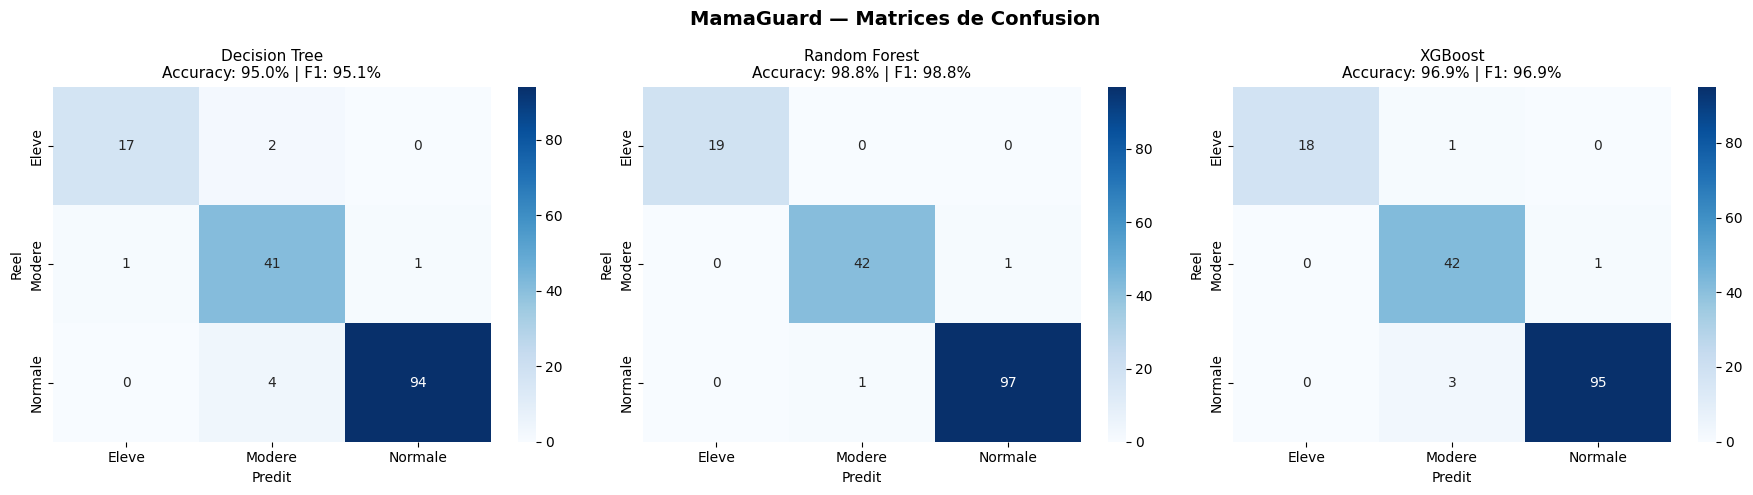


 Model Evaluation termine ✅


In [34]:


print("=" * 50)
print("   ÉTAPE 7 — MODEL EVALUATION")
print("=" * 50)

for nom, res in resultats.items():
    print(f"\n{'=' * 40}")
    print(f" {nom}")
    print(f"{'=' * 40}")
    print(f" Accuracy  : {res['accuracy']*100:.2f}%")
    print(f" F1-Score  : {res['f1_score']*100:.2f}%")
    print(f"\n Rapport detaille :")
    print(classification_report(
        y_test, res['y_pred'],
        target_names=le.classes_
    ))

# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MamaGuard — Matrices de Confusion',
             fontsize=14, fontweight='bold')

for idx, (nom, res) in enumerate(resultats.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=axes[idx]
    )
    axes[idx].set_title(
        f"{nom}\nAccuracy: {res['accuracy']*100:.1f}% | "
        f"F1: {res['f1_score']*100:.1f}%",
        fontsize=11
    )
    axes[idx].set_xlabel('Predit')
    axes[idx].set_ylabel('Reel')

plt.tight_layout()
plt.savefig('evaluation_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Model Evaluation termine ✅")

In [36]:
import pickle

print("=" * 50)
print("   ÉTAPE 8 — MODEL SELECTION")
print("=" * 50)

# Tableau comparatif
print(f"\n{'Modele':<20} {'Accuracy':>12} {'F1-Score':>12}")
print("-" * 46)
for nom, res in resultats.items():
    print(f"{nom:<20} "
          f"{res['accuracy']*100:>11.2f}% "
          f"{res['f1_score']*100:>11.2f}%")

# Sélection automatique du meilleur
meilleur_nom = max(
    resultats,
    key=lambda x: resultats[x]['f1_score']
)
meilleur_modele = resultats[meilleur_nom]['modele']

print(f"\n MEILLEUR MODELE : {meilleur_nom}")
print(f" Accuracy        : "
      f"{resultats[meilleur_nom]['accuracy']*100:.2f}%")
print(f" F1-Score        : "
      f"{resultats[meilleur_nom]['f1_score']*100:.2f}%")

print(f"""
 Justification du choix :
 Le {meilleur_nom} a ete selectionne car il obtient
 le meilleur F1-Score weighted sur le dataset
 MamaGuard. Le F1-Score est prefere a l'accuracy
 seule car il tient compte du desequilibre des
 classes (60% Normale, 25% Modere, 15% Eleve).
""")

# Sauvegarder
with open('model_mamaguard.pkl', 'wb') as f:
    pickle.dump(meilleur_modele, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print(" model_mamaguard.pkl  sauvegarde ✅")
print(" label_encoder.pkl    sauvegarde ✅")
print(" feature_names.pkl    sauvegarde ✅")
print("\n PIPELINE MAMAGUARD COMPLETE ✅")

   ÉTAPE 8 — MODEL SELECTION

Modele                   Accuracy     F1-Score
----------------------------------------------
Decision Tree              95.00%       95.06%
Random Forest              98.75%       98.75%
XGBoost                    96.88%       96.91%

 MEILLEUR MODELE : Random Forest
 Accuracy        : 98.75%
 F1-Score        : 98.75%

 Justification du choix :
 Le Random Forest a ete selectionne car il obtient
 le meilleur F1-Score weighted sur le dataset
 MamaGuard. Le F1-Score est prefere a l'accuracy
 seule car il tient compte du desequilibre des
 classes (60% Normale, 25% Modere, 15% Eleve).

 model_mamaguard.pkl  sauvegarde ✅
 label_encoder.pkl    sauvegarde ✅
 feature_names.pkl    sauvegarde ✅

 PIPELINE MAMAGUARD COMPLETE ✅
